In [ ]:
!pip list | grep torch

In [1]:
import torch

- https://pytorch.org/blog/quantization-in-practice/
- https://pytorch.org/docs/stable/quantization.html
- https://pytorch.org/docs/stable/quantization-support.html


### Mapping function and Quantization Parameters


In [2]:
# r - float tensor, r' - int tensor
# S [scaling factor] = (beta - alpha) / (beta_q - alpha_q)
# Z [zero point] =  -(alpha / S - alpha_q)

def quantize(float_tensor, scale, z):
  # Q(r) = round(r/S + Z)
  return torch.round(float_tensor / scale + z)

def dequantize(int_tensor, scale, z):
  # r' = (Q(r) - Z) * S
  return (int_tensor - z) * scale

In [3]:
from torch.ao.quantization.observer import MinMaxObserver, MovingAverageMinMaxObserver, HistogramObserver

C, L = 3, 4
normal = torch.distributions.normal.Normal(0,1)
inputs = normal.sample((C, L))
print(inputs)

tensor([[-0.0075,  0.3617, -0.4036, -0.4920],
        [ 1.9595, -1.0734, -1.1416, -0.0039],
        [ 0.9881, -1.1921,  0.5327,  1.1755]])


In [4]:
observers = [MinMaxObserver(), MovingAverageMinMaxObserver(), HistogramObserver()]
for obs in observers:
  obs(inputs)
  print(obs.__class__.__name__, obs.calculate_qparams())

MinMaxObserver (tensor([0.0124]), tensor([96], dtype=torch.int32))
MovingAverageMinMaxObserver (tensor([0.0124]), tensor([96], dtype=torch.int32))
HistogramObserver (tensor([0.0124]), tensor([97], dtype=torch.int32))


In [5]:
scale, z = observers[0].calculate_qparams()
reconstruction_error = torch.abs(dequantize(quantize(inputs, scale, z), scale, z) - inputs)
reconstruction_error

tensor([[0.0049, 0.0032, 0.0042, 0.0024],
        [0.0056, 0.0019, 0.0045, 0.0039],
        [0.0007, 0.0056, 0.0012, 0.0014]])

### Affine and Symmetric Quantization Schemes


In [6]:
import numpy as np
import matplotlib.pyplot as plt


def get_symmetric_range(x):
  beta = torch.max(x.max(), x.min().abs())
  return -beta.item(), beta.item()

def get_affine_range(x):
  return x.min().item(), x.max().item()

def plot(plt, data, scheme):
  boundaries = get_affine_range(data) if scheme == 'affine' else get_symmetric_range(data)
  a, _, _ = plt.hist(data, density=True, bins=100)
  ymin, ymax = np.quantile(a[a>0], [0.25, 0.95])
  plt.vlines(x=boundaries, ls='--', colors='purple', ymin=ymin, ymax=ymax)

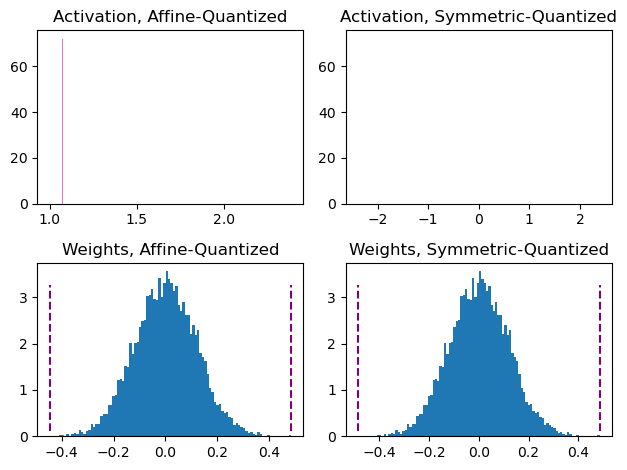

In [7]:
act =  torch.distributions.pareto.Pareto(1, 10).sample((1, 1024))
weights = torch.distributions.normal.Normal(0, 0.12).sample((3, 64, 7, 7)).flatten()

fig, axs = plt.subplots(2,2)
plot(axs[0, 0], act, 'affine')
axs[0, 0].set_title("Activation, Affine-Quantized")

plot(axs[0, 1], act, 'symmetric')
axs[0, 1].set_title("Activation, Symmetric-Quantized")

plot(axs[1, 0], weights, 'affine')
axs[1, 0].set_title("Weights, Affine-Quantized")

plot(axs[1, 1], weights, 'symmetric')
axs[1, 1].set_title("Weights, Symmetric-Quantized")

fig.tight_layout()
plt.show()

In [8]:
for qscheme in [torch.per_tensor_affine, torch.per_tensor_symmetric]:
  obs = MovingAverageMinMaxObserver(qscheme=qscheme)
  obs(inputs)
  print(f"Qscheme: {qscheme} | {obs.calculate_qparams()}")

Qscheme: torch.per_tensor_affine | (tensor([0.0124]), tensor([96], dtype=torch.int32))
Qscheme: torch.per_tensor_symmetric | (tensor([0.0154]), tensor([128]))


### Per-Tensor and Per-Channel Quantization Schemes


In [9]:
from torch.ao.quantization.observer import MovingAveragePerChannelMinMaxObserver

obs = MovingAveragePerChannelMinMaxObserver(ch_axis = 0)  # calculate qparams for all `C` channels separately
obs(inputs)
print(obs.calculate_qparams())

(tensor([0.0033, 0.0122, 0.0093]), tensor([147,  94, 128], dtype=torch.int32))


For weights quantization, symmetric-per-channel quantization provides better accuracies; per-tensor quantization performs poorly, possibly due to high variance in conv weights across channels from batchnorm folding.
[https://arxiv.org/abs/2004.09602]


https://github.com/pytorch/pytorch/blob/748d9d24940cd17938df963456c90fa1a13f3932/torch/ao/quantization/observer.py#L258


### Backend Engine


In [10]:
backend = 'fbgemm' #'fbgemm' if x86 else 'qnnpack' intel - oneDNN
qconfig = torch.ao.quantization.get_default_qconfig(backend)
torch.backends.quantized.engine = backend

GPUs - via TensorRT and cuDNN
https://pytorch.org/docs/stable/quantization.html#note-for-native-cpu-backends


### QConfig


In [11]:
my_qconfig = torch.ao.quantization.QConfig(
  activation=MovingAverageMinMaxObserver.with_args(qscheme=torch.per_tensor_affine),
  weight=MovingAveragePerChannelMinMaxObserver.with_args(qscheme=torch.qint8))

my_qconfig

QConfig(activation=functools.partial(<class 'torch.ao.quantization.observer.MovingAverageMinMaxObserver'>, qscheme=torch.per_tensor_affine){}, weight=functools.partial(<class 'torch.ao.quantization.observer.MovingAveragePerChannelMinMaxObserver'>, qscheme=torch.qint8){})

### Eager Mode v/s FX Graph Mode


- Eager Mode Quantization is a beta feature. User needs to do fusion and specify where quantization and dequantization happens manually, also it only supports modules and not functionals.
- FX Graph Mode Quantization is a new automated quantization framework in PyTorch, and currently it’s a prototype feature. It improves upon Eager Mode Quantization by adding support for functionals and automating the quantization process, although people might need to refactor the model to make the model compatible with FX Graph Mode Quantization (symbolically traceable with torch.fx)


FX Graph Mode automatically fuses eligible modules, inserts Quant/DeQuant stubs, calibrates the model and returns a quantized module - all in two method calls - but only for networks that are symbolic traceable. The examples below contain the calls using Eager Mode and FX Graph Mode for comparison.
https://pytorch.org/docs/stable/fx.html#torch.fx.symbolic_trace


In [12]:
def f(a, b):
    if b == True:
        return a
    else:
        return a * 2

In [ ]:
f = torch.fx.symbolic_trace(f, concrete_args={'b': False})
assert f(3, True) == 6

https://pytorch.org/docs/stable/fx.html


### Post-Training Dynamic/Weight-only Quantization


Here the model’s weights are pre-quantized; the activations are quantized on-the-fly (“dynamic”) during inference. The simplest of all approaches, it has a one line API call in torch.quantization.quantize_dynamic. Currently only Linear and Recurrent (LSTM, GRU, RNN) layers are supported for dynamic quantization

- Can result in higher accuracies since the clipping range is exactly calibrated for each input
- Calibrating and quantizing the activations at each layer during runtime can add to the compute overhead


In [16]:
from torch import nn

# toy model
m = nn.Sequential(
  nn.Conv2d(2, 64, (8,)),
  nn.ReLU(),
  nn.Linear(16, 10),
  nn.LSTM(10, 10))

m.eval()

Sequential(
  (0): Conv2d(2, 64, kernel_size=(8,), stride=(1, 1))
  (1): ReLU()
  (2): Linear(in_features=16, out_features=10, bias=True)
  (3): LSTM(10, 10)
)

In [17]:
## EAGER MODE
from torch.ao.quantization import quantize_dynamic

model_quantized = quantize_dynamic(
    model=m, qconfig_spec={nn.LSTM, nn.Linear}, dtype=torch.qint8, inplace=False
)

In [18]:
## FX MODE
from torch.ao.quantization import quantize_fx

example_inputs = (torch.randn(1, 3, 224, 224),)
qconfig_dict = {"": torch.ao.quantization.default_dynamic_qconfig}  # An empty key denotes the default applied to all modules
model_prepared = quantize_fx.prepare_fx(m, qconfig_dict, example_inputs)
model_quantized = quantize_fx.convert_fx(model_prepared)

/home/work/miniconda3/envs/mlops/lib/python3.12/site-packages/torch/ao/quantization/quantize_fx.py:146: FutureWarning: Passing a QConfig dictionary to prepare is deprecated and will not be supported in a future version. Please pass in a QConfigMapping instead.
  prepared = prepare(
/home/work/miniconda3/envs/mlops/lib/python3.12/site-packages/torch/ao/nn/quantized/reference/modules/rnn.py:455: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(
/home/work/miniconda3/envs/mlops/lib/python3.12/site-packages/torch/ao/nn/quantized/reference/modules/rnn.py:461: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(


In [19]:
torch.ao.quantization.default_dynamic_qconfig

QConfig(activation=functools.partial(<class 'torch.ao.quantization.observer.PlaceholderObserver'>, dtype=torch.quint8, quant_min=0, quant_max=255, is_dynamic=True){}, weight=functools.partial(<class 'torch.ao.quantization.observer.MinMaxObserver'>, dtype=torch.qint8, qscheme=torch.per_tensor_symmetric){})

### Post-Training Static Quantization (PTQ)


PTQ also pre-quantizes model weights but instead of calibrating activations on-the-fly, the clipping range is pre-calibrated and fixed (“static”) using validation data. Activations stay in quantized precision between operations during inference. About 100 mini-batches of representative data are sufficient to calibrate the observers

- Static quantization has faster inference than dynamic quantization because it eliminates the float<->int conversion costs between layers
- Static quantized models may need regular re-calibration to stay robust against distribution-drift


In [20]:
# Static quantization of a model consists of the following steps:

#     Fuse modules
#     Insert Quant/DeQuant Stubs
#     Prepare the fused module (insert observers before and after layers)
#     Calibrate the prepared module (pass it representative data)
#     Convert the calibrated module (replace with quantized version)

import torch
from torch import nn
import copy

backend = "fbgemm"  # running on a x86 CPU. Use "qnnpack" if running on ARM.

model = nn.Sequential(
     nn.Conv2d(2, 64, 3),
     nn.ReLU(),
     nn.Conv2d(64, 128, 3),
     nn.ReLU()
)

In [21]:
## EAGER MODE
m = copy.deepcopy(model)
m.eval()

"""Fuse
- Inplace fusion replaces the first module in the sequence with the fused module, and the rest with identity modules
"""
torch.ao.quantization.fuse_modules(m, ['0','1'], inplace=True) # fuse first Conv-ReLU pair
torch.ao.quantization.fuse_modules(m, ['2','3'], inplace=True) # fuse second Conv-ReLU pair

"""Insert stubs"""
m = nn.Sequential(torch.ao.quantization.QuantStub(),
                  *m,
                  torch.ao.quantization.DeQuantStub())

"""Prepare"""
m.qconfig = torch.ao.quantization.get_default_qconfig(backend)
torch.ao.quantization.prepare(m, inplace=True)

"""Calibrate
- This example uses random data for convenience. Use representative (validation) data instead.
"""
with torch.inference_mode():
  for _ in range(10):
    x = torch.rand(1, 2, 28, 28)
    m(x)

"""Convert"""
torch.ao.quantization.convert(m, inplace=True)

"""Check"""
print(m[1].weight().element_size()) # 1 byte instead of 4 bytes for FP32

1


/home/work/miniconda3/envs/mlops/lib/python3.12/site-packages/torch/ao/quantization/observer.py:229: UserWarning: Please use quant_min and quant_max to specify the range for observers.                     reduce_range will be deprecated in a future release of PyTorch.
  warnings.warn(


In [22]:
m[1].weight()

tensor([[[[ 0.0018,  0.1054,  0.0345],
          [ 0.0473,  0.0418,  0.0909],
          [ 0.2145, -0.1345, -0.2290]],

         [[ 0.1000, -0.0309,  0.1145],
          [-0.2308, -0.0582,  0.2054],
          [-0.2218, -0.1581,  0.1509]]],


        [[[ 0.1108,  0.1645,  0.2069],
          [-0.0195,  0.1026, -0.0326],
          [-0.1222,  0.1254, -0.0277]],

         [[-0.0472,  0.0554,  0.0554],
          [-0.0961, -0.0570, -0.1466],
          [-0.0228, -0.1222, -0.0424]]],


        [[[ 0.0668, -0.0261,  0.0493],
          [ 0.1422,  0.1756, -0.0769],
          [ 0.0522,  0.1393,  0.0319]],

         [[-0.0377,  0.1785, -0.1858],
          [ 0.1712, -0.0522,  0.0160],
          [-0.1524, -0.0247, -0.0827]]],


        ...,


        [[[ 0.1818,  0.1835,  0.1669],
          [ 0.0413,  0.2099, -0.0380],
          [-0.0529, -0.1190,  0.0446]],

         [[-0.1273,  0.0033, -0.0793],
          [-0.1554, -0.0793,  0.1107],
          [-0.1025, -0.0744,  0.1124]]],


        [[[ 0.0519, -0.18

In [23]:
## FX GRAPH
from torch.ao.quantization import quantize_fx

m = copy.deepcopy(model)
m.eval()
qconfig_dict = {"": torch.ao.quantization.get_default_qconfig(backend)}

# Prepare
example_inputs = (torch.randn(1, 3, 224, 224),)
model_prepared = quantize_fx.prepare_fx(m, qconfig_dict, example_inputs)

# Calibrate - Use representative (validation) data.
with torch.inference_mode():
  for _ in range(10):
    x = torch.rand(1, 2, 28, 28)
    model_prepared(x)

# quantize
model_quantized = quantize_fx.convert_fx(model_prepared)

### SENSITIVITY ANALYSIS


In [24]:
# ONE-AT-A-TIME SENSITIVITY ANALYSIS

for quantized_layer, _ in model.named_modules():
  print("Only quantizing layer: ", quantized_layer)

  # The module_name key allows module-specific qconfigs.
  qconfig_dict = {"": None,
  "module_name":[(quantized_layer, torch.quantization.get_default_qconfig(backend))]}

  example_inputs = (torch.randn(1, 3, 224, 224),)
  model_prepared = quantize_fx.prepare_fx(model, qconfig_dict, example_inputs)
  # calibrate
  model_quantized = quantize_fx.convert_fx(model_prepared)
  # evaluate(model)

Only quantizing layer:  
Only quantizing layer:  0
Only quantizing layer:  1
Only quantizing layer:  2
Only quantizing layer:  3


/home/work/miniconda3/envs/mlops/lib/python3.12/site-packages/torch/ao/quantization/observer.py:1315: UserWarning: must run observer before calling calculate_qparams.                                    Returning default scale and zero point 
  warnings.warn(


Numeric Suite - https://pytorch.org/tutorials/prototype/numeric_suite_tutorial.html


In [25]:
import numpy as np
import torch
import torch.nn as nn
import torchvision
from torchvision import datasets
import torchvision.transforms as transforms
import os
import torch.ao.quantization
import torch.ao.ns._numeric_suite as ns
from torch.ao.quantization import (
    default_eval_fn,
    default_qconfig,
    quantize,
)

In [28]:
import os
from pathlib import Path

torch_cache_dir = Path("./torch_cache")
torch_cache_dir.mkdir(parents=True, exist_ok=True)
os.environ["TORCH_HOME"] = str(torch_cache_dir.resolve())
torch.hub.set_dir(str(torch_cache_dir.resolve()))

#float_model = torchvision.models.quantization.resnet18(pretrained=True, quantize=False)
float_model = torchvision.models.quantization.resnet18(
    weights=torchvision.models.ResNet18_Weights.DEFAULT,
    quantize=False,
)

float_model.to('cpu')
float_model.eval()
float_model.fuse_model()
float_model.qconfig = torch.quantization.default_qconfig
img_data = (torch.rand(2, 3, 10, 10, dtype=torch.float), torch.randint(0, 1, (2,), dtype=torch.long))
qmodel = quantize(float_model, default_eval_fn, [[img_data]], inplace=False)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /home/work/WORK/MIPT/study/repos/MTAI2026-Deep-learning-frameworks-seminars/seminar_5/torch_cache/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:01<00:00, 34.0MB/s]


In [29]:
def compute_error(x, y):
    Ps = torch.norm(x)
    Pn = torch.norm(x - y)
    return 20 * torch.log10(Ps/Pn)

wt_compare_dict = ns.compare_weights(float_model.state_dict(), qmodel.state_dict())
for key in wt_compare_dict:
    print(key, compute_error(wt_compare_dict[key]['float'], wt_compare_dict[key]['quantized'].dequantize()))

print("---")

act_compare_dict = ns.compare_model_outputs(float_model, qmodel, img_data[0])
for key in act_compare_dict:
    print(key, compute_error(act_compare_dict[key]['float'][0], act_compare_dict[key]['quantized'][0].dequantize()))


conv1.weight tensor(31.6638)
layer1.0.conv1.weight tensor(30.6450)
layer1.0.conv2.weight tensor(31.1528)
layer1.1.conv1.weight tensor(32.1438)
layer1.1.conv2.weight tensor(31.2477)
layer2.0.conv1.weight tensor(30.9890)
layer2.0.conv2.weight tensor(28.8233)
layer2.0.downsample.0.weight tensor(31.5558)
layer2.1.conv1.weight tensor(30.7668)
layer2.1.conv2.weight tensor(28.4516)
layer3.0.conv1.weight tensor(30.9247)
layer3.0.conv2.weight tensor(26.6841)
layer3.0.downsample.0.weight tensor(28.7825)
layer3.1.conv1.weight tensor(28.9707)
layer3.1.conv2.weight tensor(25.6784)
layer4.0.conv1.weight tensor(26.8495)
layer4.0.conv2.weight tensor(25.8394)
layer4.0.downsample.0.weight tensor(28.6355)
layer4.1.conv1.weight tensor(26.8758)
layer4.1.conv2.weight tensor(28.4319)
fc._packed_params._packed_params tensor(32.6505)
---
conv1.stats tensor(37.5070, grad_fn=<MulBackward0>)
layer1.0.conv1.stats tensor(29.9825, grad_fn=<MulBackward0>)
layer1.0.conv2.stats tensor(28.5288, grad_fn=<MulBackward0>)
l

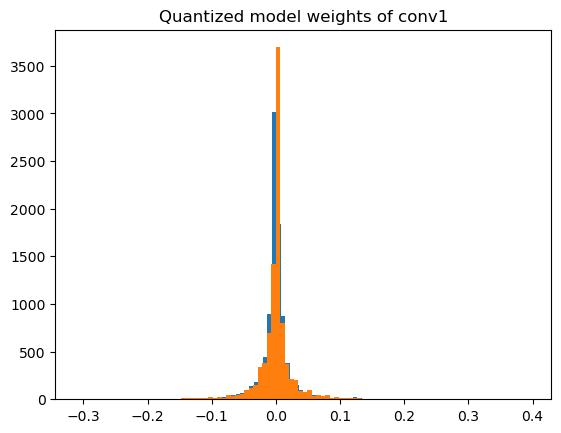

In [30]:
import matplotlib.pyplot as plt

f = wt_compare_dict['conv1.weight']['float'].flatten()
plt.hist(f, bins = 100)

q = wt_compare_dict['conv1.weight']['quantized'].flatten().dequantize()
plt.hist(q, bins = 100)
plt.title("Quantized model weights of conv1")
plt.show()

### RECOMMENDATIONS FOR YOUR WORKFLOW


![](https://drive.google.com/uc?export=view&id=1ij7GElwiKFNmJ221aKpkDRwMj5i-2DLh)


- Large (10M+ parameters) models are more robust to quantization error
- Quantizing a model from a FP32 checkpoint provides better accuracy than training an INT8 model from scratch
- Dynamic Quantization is an easy first step, especially if your model has many Linear or Recurrent layers
- Use symmetric-per-channel quantization with MinMax observers for quantizing weights. Use affine-per-tensor quantization with MovingAverageMinMax observers for quantizing activations
- Use metrics like SQNR to identify which layers are most suscpetible to quantization error. Turn off quantization on these layers


Eager mode https://pytorch.org/docs/stable/quantization.html#eager-mode-quantization

- https://pytorch.org/docs/stable/quantization.html#post-training-dynamic-quantization
- https://pytorch.org/docs/stable/quantization.html#post-training-static-quantization

FX Graph https://pytorch.org/docs/stable/quantization.html#prototype-fx-graph-mode-quantization

- https://pytorch.org/tutorials/prototype/fx_graph_mode_ptq_static.html
- https://pytorch.org/tutorials/prototype/fx_graph_mode_ptq_dynamic.html


## New forkflow with torchao


In [ ]:
!pip install torchao

In [31]:
import copy
import torch

class ToyLinearModel(torch.nn.Module):
    def __init__(self, m: int, n: int, k: int):
        super().__init__()
        self.linear1 = torch.nn.Linear(m, n, bias=False)
        self.linear2 = torch.nn.Linear(n, k, bias=False)

    def forward(self, x):
        x = self.linear1(x)
        x = self.linear2(x)
        return x

model = ToyLinearModel(1024, 1024, 1024).eval()

# Optional: compile model for faster inference and generation
model = torch.compile(model, mode="max-autotune", fullgraph=True)
model_f32 = copy.deepcopy(model)


In [33]:
from torchao.quantization import Int4DynamicActivationInt4WeightConfig, quantize_
quantize_(model, Int4DynamicActivationInt4WeightConfig())

In [34]:
from torchao.utils import (
    benchmark_model,
    unwrap_tensor_subclass,
)

num_runs = 100
torch._dynamo.reset()
example_inputs = (torch.randn(1, 1024, dtype=torch.float32),)
f32_time = benchmark_model(model_f32, num_runs, example_inputs)
int4_time = benchmark_model(model, num_runs, example_inputs)

print("f32 mean time: %0.3f ms" % f32_time)
print("int4 mean time: %0.3f ms" % int4_time)
print("speedup: %0.1fx" % (f32_time / int4_time))

f32 mean time: 0.072 ms
int4 mean time: 0.030 ms
speedup: 2.4x


In [35]:
import os
torch.save(model, "/tmp/int4_model.pt")
torch.save(model_f32, "/tmp/f32_model.pt")
int4_model_size_mb = os.path.getsize("/tmp/int4_model.pt") / 1024 / 1024
f32_model_size_mb = os.path.getsize("/tmp/f32_model.pt") / 1024 / 1024

print("int4 model size: %.2f MB" % int4_model_size_mb)

print("f32 model size: %.2f MB" % f32_model_size_mb)


int4 model size: 1.01 MB
f32 model size: 8.00 MB


### Neural Network Compression Framework (NNCF)


In [ ]:
!git clone https://github.com/openvinotoolkit/nncf

In [ ]:
# %%capture
#%cd nncf
import sys
%cd  /home/work/WORK/MIPT/repo/nncf
!{sys.executable} -m pip install .[torch]
#!pip install .[torch]
#%cd /content

In [37]:
import torch
import nncf.torch  # Important - must be imported before any other external package that depends on torch

https://github.com/openvinotoolkit/nncf/tree/develop
https://github.com/openvinotoolkit/nncf/blob/develop/docs/compression_algorithms/Quantization.md
https://github.com/openvinotoolkit/nncf/blob/develop/examples/torch/classification/configs/quantization/inception_v3_imagenet_int8.json

https://dev-discuss.pytorch.org/t/torch-ao-quantization-migration-plan/2810
https://docs.pytorch.org/ao/stable


**Домашнее задание**: реализовать Post Training Quantization для предобученной float32 torch2 модели на выбранном наборе данных. Квантизация обязательно должна проводиться с использованием калибровочной подвыборки. К результатам прилагаются мини результаты исследования влияния гиперпараметров квантизации (см. начало ноутбка). Необходимо показать разные варианты с учетом и без SENSITIVITY анализа. Разрешается использовать дополнительные фреймворки после обсуждения. Важно наличие таблиц скорость / качество / размер.


Берем:

- датасет: CIFAR10
- модель: предобученная на CIFAR10 через torch.hub модель cifar10_resnet20
- метод: Post-Training Static Quantization
- backend: fbgemm

pipeline:

- FP32 baseline
- PTQ с несколькими гиперпараметрами
- PTQ + sensitivity analysis
- таблицы quality / speed / size


In [ ]:
import os
import time
import copy
import tempfile
from pathlib import Path

import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

from torch.ao.quantization import QConfig, QConfigMapping
from torch.ao.quantization.observer import (
    HistogramObserver,
    MovingAverageMinMaxObserver,
    PerChannelMinMaxObserver,
)
from torch.ao.quantization.quantize_fx import prepare_fx, convert_fx


device = torch.device("cpu")
backend = "fbgemm"
torch.backends.quantized.engine = backend
torch.set_num_threads(max(1, os.cpu_count() // 2))

torch_cache_dir = Path("./torch_cache")
torch_cache_dir.mkdir(parents=True, exist_ok=True)
os.environ["TORCH_HOME"] = str(torch_cache_dir.resolve())
torch.hub.set_dir(str(torch_cache_dir.resolve()))

In [3]:
# Датасет CIFAR10

cifar10_mean = (0.4914, 0.4822, 0.4465)
cifar10_std = (0.2023, 0.1994, 0.2010)

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(cifar10_mean, cifar10_std),
])

train_dataset = datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform,
)

val_dataset = datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=transform,
)

100%|██████████| 170M/170M [00:06<00:00, 26.0MB/s] 


Extracting ./data/cifar-10-python.tar.gz to ./data


/home/work/miniconda3/envs/mlops/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Files already downloaded and verified


In [4]:
def make_subset(dataset, n_samples):
    n_samples = min(n_samples, len(dataset))
    return Subset(dataset, list(range(n_samples)))

calib_dataset = make_subset(train_dataset, 32 * 128)
val_eval_dataset = make_subset(val_dataset, 5000)

calib_loader = DataLoader(
    calib_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=4,
)

val_loader = DataLoader(
    val_eval_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=4,
)

In [5]:
# Предобученная модель на CIFAR10

float_model = torch.hub.load(
    "chenyaofo/pytorch-cifar-models",
    "cifar10_resnet20",
    pretrained=True,
    trust_repo=True,
).to(device).eval()

Downloading: "https://github.com/chenyaofo/pytorch-cifar-models/zipball/master" to /home/work/WORK/MIPT/study/repos/MTAI2026-Deep-learning-frameworks-seminars/seminar_5/torch_cache/master.zip
Downloading: "https://github.com/chenyaofo/pytorch-cifar-models/releases/download/resnet/cifar10_resnet20-4118986f.pt" to /home/work/WORK/MIPT/study/repos/MTAI2026-Deep-learning-frameworks-seminars/seminar_5/torch_cache/checkpoints/cifar10_resnet20-4118986f.pt
100%|██████████| 1.09M/1.09M [00:00<00:00, 3.93MB/s]


In [7]:
@torch.inference_mode()
def evaluate_top1(model, loader):
    model.eval()
    correct = 0
    total = 0

    for x, y in loader:
        x = x.to(device)
        y = y.to(device)
        logits = model(x)
        pred = logits.argmax(dim=1)
        correct += (pred == y).sum().item()
        total += y.numel()

    return correct / total

@torch.inference_mode()
def calibrate(model, loader, max_batches):
    model.eval()
    for i, (x, _) in enumerate(loader):
        if i >= max_batches:
            break
        model(x.to(device))

@torch.inference_mode()
def measure_latency_ms(model, loader, warmup=10, iters=50):
    model.eval()

    batches = []
    for i, (x, _) in enumerate(loader):
        batches.append(x.to(device))
        if len(batches) >= iters:
            break

    sample = batches[0]

    for _ in range(warmup):
        model(sample)

    times = []
    for x in batches:
        t0 = time.perf_counter()
        model(x)
        t1 = time.perf_counter()
        times.append((t1 - t0) * 1000)

    return sum(times) / len(times)

def model_size_mb(model):
    with tempfile.NamedTemporaryFile(suffix=".pt") as f:
        torch.save(model.state_dict(), f.name)
        return Path(f.name).stat().st_size / (1024 ** 2)

def make_qconfig(act_observer_name="moving"):
    if act_observer_name == "moving":
        act_observer = MovingAverageMinMaxObserver
    elif act_observer_name == "hist":
        act_observer = HistogramObserver
    else:
        raise ValueError(f"Unknown activation observer: {act_observer_name}")

    return QConfig(
        activation=act_observer.with_args(
            dtype=torch.quint8,
            qscheme=torch.per_tensor_affine,
        ),
        weight=PerChannelMinMaxObserver.with_args(
            dtype=torch.qint8,
            qscheme=torch.per_channel_symmetric,
            ch_axis=0,
        ),
    )

**PTQ через FX**


In [9]:
example_inputs = (torch.randn(1, 3, 32, 32),)

def ptq_fx(float_model, qconfig_mapping, calib_loader, calib_batches):
    model = copy.deepcopy(float_model).to(device).eval()
    prepared = prepare_fx(model, qconfig_mapping, example_inputs)
    calibrate(prepared, calib_loader, max_batches=calib_batches)
    quantized = convert_fx(prepared)
    quantized.eval()
    return quantized

**Baseline**


In [10]:
float_acc = evaluate_top1(float_model, val_loader)
float_latency = measure_latency_ms(float_model, val_loader)
float_size = model_size_mb(float_model)

baseline_df = pd.DataFrame([{
    "name": "fp32_baseline",
    "top1": float_acc,
    "acc_drop_pp": 0.0,
    "latency_ms": float_latency,
    "speedup_x": 1.0,
    "size_mb": float_size,
    "compression_x": 1.0,
    "observer": "none",
    "calib_batches": 0,
    "sensitivity_excluded": "",
}])

baseline_df

,name,top1,acc_drop_pp,latency_ms,speedup_x,size_mb,compression_x,observer,calib_batches,sensitivity_excluded
0,fp32_baseline,0.9256,0.0,14.118722,1.0,1.084352,1.0,none,0,


**PTQ без sensitivity analysis**


In [11]:
results = []

for observer_name in ["moving", "hist"]:
    for calib_batches in [8, 32, 128]:
        qconfig = make_qconfig(observer_name)
        qconfig_mapping = QConfigMapping().set_global(qconfig)

        qmodel = ptq_fx(
            float_model=float_model,
            qconfig_mapping=qconfig_mapping,
            calib_loader=calib_loader,
            calib_batches=calib_batches,
        )

        acc = evaluate_top1(qmodel, val_loader)
        latency = measure_latency_ms(qmodel, val_loader)
        size = model_size_mb(qmodel)

        results.append({
            "name": f"ptq_{observer_name}_calib{calib_batches}",
            "top1": acc,
            "acc_drop_pp": 100 * (float_acc - acc),
            "latency_ms": latency,
            "speedup_x": float_latency / latency,
            "size_mb": size,
            "compression_x": float_size / size,
            "observer": observer_name,
            "calib_batches": calib_batches,
            "sensitivity_excluded": "",
        })

results_df = pd.DataFrame(results).sort_values("top1", ascending=False)
results_df

,name,top1,acc_drop_pp,latency_ms,speedup_x,size_mb,compression_x,observer,calib_batches,sensitivity_excluded
4,ptq_hist_calib32,0.9138,1.18,11.999404,1.176619,0.316942,3.421294,hist,32,
5,ptq_hist_calib128,0.9132,1.24,11.865566,1.189890,0.316942,3.421294,hist,128,
3,ptq_hist_calib8,0.9130,1.26,11.886340,1.187811,0.316942,3.421294,hist,8,
0,ptq_moving_calib8,0.9122,1.34,12.117113,1.165189,0.316942,3.421294,moving,8,
2,ptq_moving_calib128,0.9122,1.34,7.618825,1.853137,0.316942,3.421294,moving,128,
1,ptq_moving_calib32,0.9110,1.46,8.074943,1.748461,0.316942,3.421294,moving,32,


- PTQ позволила уменьшить размер модели примерно в 3.4x.
- Потеря качества после квантизации оказалась небольшой: около 1.2-1.5 п.п..
- На CPU получено ускорение inference до 1.85x.
- HistogramObserver дал лучший результат по качеству.
- Наиболее быстрый вариант получен с MovingAverageMinMaxObserver, но лучший баланс качества и скорости показывает HistogramObserver при 32 calibration batches.


**Sensitivity analysis**


In [12]:
target_module_names = [
    name
    for name, module in float_model.named_modules()
    if isinstance(module, (nn.Conv2d, nn.Linear))
]

sensitivity_rows = []
base_qconfig = make_qconfig("hist")

for name in target_module_names:
    qconfig_mapping = (
        QConfigMapping()
        .set_global(None)
        .set_module_name(name, base_qconfig)
    )

    qmodel_one_layer = ptq_fx(
        float_model=float_model,
        qconfig_mapping=qconfig_mapping,
        calib_loader=calib_loader,
        calib_batches=32,
    )

    acc = evaluate_top1(qmodel_one_layer, val_loader)

    sensitivity_rows.append({
        "module": name,
        "top1": acc,
        "drop_pp": 100 * (float_acc - acc),
    })

sensitivity_df = pd.DataFrame(sensitivity_rows).sort_values("drop_pp", ascending=False)
sensitivity_df.head(10)

,module,top1,drop_pp
0,conv1,0.9128,1.28
7,layer2.0.conv1,0.9246,0.10
12,layer2.2.conv1,0.9248,0.08
2,layer1.0.conv2,0.9248,0.08
4,layer1.1.conv2,0.9250,0.06
18,layer3.1.conv2,0.9250,0.06
15,layer3.0.conv2,0.9250,0.06
14,layer3.0.conv1,0.9252,0.04
3,layer1.1.conv1,0.9252,0.04
17,layer3.1.conv1,0.9252,0.04


- Наиболее чувствительным слоем оказался входной слой conv1.
- Его квантизация отдельно приводит к заметному падению accuracy (1.28 п.п.), что существенно выше влияния остальных слоев.
- Большинство внутренних сверточных слоев модели значительно устойчивее к квантизации: их вклад в потерю качества не превышает 0.1 п.п..
- Следовательно, для улучшения компромисса между quality и efficiency разумно исключить conv1 и, возможно, еще 1-2 наиболее чувствительных слоя из полной квантизации.


**PTQ с sensitivity analysis**


In [13]:
sensitive_modules = sensitivity_df.head(3)["module"].tolist()
sensitive_modules

['conv1', 'layer2.0.conv1', 'layer2.2.conv1']

In [14]:
qconfig_mapping_sa = QConfigMapping().set_global(make_qconfig("hist"))

for name in sensitive_modules:
    qconfig_mapping_sa = qconfig_mapping_sa.set_module_name(name, None)

qmodel_sa = ptq_fx(
    float_model=float_model,
    qconfig_mapping=qconfig_mapping_sa,
    calib_loader=calib_loader,
    calib_batches=32,
)

acc_sa = evaluate_top1(qmodel_sa, val_loader)
latency_sa = measure_latency_ms(qmodel_sa, val_loader)
size_sa = model_size_mb(qmodel_sa)

sa_df = pd.DataFrame([{
    "name": "ptq_hist_calib32_with_sensitivity",
    "top1": acc_sa,
    "acc_drop_pp": 100 * (float_acc - acc_sa),
    "latency_ms": latency_sa,
    "speedup_x": float_latency / latency_sa,
    "size_mb": size_sa,
    "compression_x": float_size / size_sa,
    "observer": "hist",
    "calib_batches": 32,
    "sensitivity_excluded": ", ".join(sensitive_modules),
}])

sa_df

,name,top1,acc_drop_pp,latency_ms,speedup_x,size_mb,compression_x,observer,calib_batches,sensitivity_excluded
0,ptq_hist_calib32_with_sensitivity,0.9256,0.0,12.423756,1.136429,0.354708,3.057031,hist,32,"conv1, layer2.0.conv1, layer2.2.conv1"


- Обычный PTQ дал хорошее сжатие (~3.42x) и ускорение (до 1.85x), но сопровождался потерей точности (1.18-1.46 п.п.).
- Sensitivity analysis показал, что основной вклад в деградацию качества вносит conv1, а также несколько ранних сверточных слоев.
- Исключение conv1, layer2.0.conv1 и layer2.2.conv1 из квантизации позволило полностью восстановить baseline accuracy.
- При этом модель все равно осталась быстрее FP32 (1.14x) и более чем в 3x меньше по размеру.


**Финальная таблица**


In [15]:
final_df = pd.concat([baseline_df, results_df, sa_df], ignore_index=True)

final_df = final_df[
    [
        "name",
        "top1",
        "acc_drop_pp",
        "latency_ms",
        "speedup_x",
        "size_mb",
        "compression_x",
        "observer",
        "calib_batches",
        "sensitivity_excluded",
    ]
].sort_values("top1", ascending=False)

report_df = final_df.copy()
report_df["top1"] = report_df["top1"].map(lambda x: round(100 * x, 2))
report_df["acc_drop_pp"] = report_df["acc_drop_pp"].map(lambda x: round(x, 2))
report_df["latency_ms"] = report_df["latency_ms"].map(lambda x: round(x, 2))
report_df["speedup_x"] = report_df["speedup_x"].map(lambda x: round(x, 2))
report_df["size_mb"] = report_df["size_mb"].map(lambda x: round(x, 2))
report_df["compression_x"] = report_df["compression_x"].map(lambda x: round(x, 2))

report_df

,name,top1,acc_drop_pp,latency_ms,speedup_x,size_mb,compression_x,observer,calib_batches,sensitivity_excluded
0,fp32_baseline,92.56,0.00,14.12,1.00,1.08,1.00,none,0,
7,ptq_hist_calib32_with_sensitivity,92.56,0.00,12.42,1.14,0.35,3.06,hist,32,"conv1, layer2.0.conv1, layer2.2.conv1"
1,ptq_hist_calib32,91.38,1.18,12.00,1.18,0.32,3.42,hist,32,
2,ptq_hist_calib128,91.32,1.24,11.87,1.19,0.32,3.42,hist,128,
3,ptq_hist_calib8,91.30,1.26,11.89,1.19,0.32,3.42,hist,8,
4,ptq_moving_calib8,91.22,1.34,12.12,1.17,0.32,3.42,moving,8,
5,ptq_moving_calib128,91.22,1.34,7.62,1.85,0.32,3.42,moving,128,
6,ptq_moving_calib32,91.10,1.46,8.07,1.75,0.32,3.42,moving,32,


Лучший общий результат: **ptq_hist_calib32_with_sensitivity**

- качество полностью сохранено: 92.56% против 92.56% у baseline;
- модель все равно быстрее: 12.42 ms против 14.12 ms, то есть 1.14x;
- модель существенно меньше: 0.35 MB против 1.08 MB, то есть 3.06x.

Без sensitivity analysis лучший обычный PTQ-вариант: **ptq_hist_calib32**

- 91.38%, падение 1.18 п.п.
- 1.18x ускорение
- 3.42x сжатие

По гиперпараметрам:

- HistogramObserver стабильно лучше по качеству, чем MovingAverageMinMaxObserver.
- Размер calibration subset почти не меняет accuracy в блоке hist: 8, 32, 128 дали очень близкие результаты.
- Самый быстрый вариант: ptq_moving_calib128 (1.85x), но он хуже по quality.
- Для лучшего компромисса quality / speed / size самый подходящий это вариант с sensitivity.


### Выводы

В работе была реализована Post-Training Static Quantization для предобученной float32 модели `cifar10_resnet20` на датасете `CIFAR10` с использованием calibration subset. В качестве baseline FP32-модель показала `92.56%` top-1 accuracy, `14.12 ms` latency и размер `1.08 MB`.

`Без sensitivity analysis` лучшие результаты показал вариант `ptq_hist_calib32`: он обеспечил `91.38%` accuracy, ускорение `1.18x` и сжатие модели в `3.42x`. Таким образом, обычный PTQ дал небольшую потерю качества (`1.18 п.п.`) при заметном выигрыше по размеру и скорости.

`Sensitivity analysis` показал, что наиболее чувствительным слоем является `conv1`, а также несколько ранних сверточных слоев. Исключение `conv1`, `layer2.0.conv1` и `layer2.2.conv1` из квантизации позволило полностью восстановить baseline accuracy (`92.56%`) при сохранении ускорения `1.14x` и сжатия модели в `3.06x`.

Итоговый вывод: PTQ позволяет существенно уменьшить размер модели и ускорить inference на CPU. Наилучший компромисс между качеством, скоростью и размером в данном эксперименте показал вариант `ptq_hist_calib32_with_sensitivity`.
